# ENSO Diagnostics Notebook (Member Diagnostics → Ensemble Mean)

This notebook mirrors a common CESM workflow:

1. Load each ensemble member
2. Compute diagnostics for that member
3. Store results
4. Average diagnostics across members for plotting

This approach is appropriate when diagnostics are **non‑linear** (PDFs, thresholds, ENSO binning, etc.).

## Imports

In [12]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt

## Helper: build ensemble member names

In [13]:
def build_members(case_base, n_members):
    return [f"{case_base}.{i:03d}" for i in range(1, n_members+1)]

## Dataset loader

In [14]:
def load_member(case, case_type, var):

    if case_type == "cesm2":
        root = "/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1/"

    elif case_type == "cesm1":
        root = "/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/monthly/"

    files = glob.glob(f"{root}/{var}/{case}*.nc")

    ds = xr.open_mfdataset(files, combine="by_coords", parallel=True)

    return ds[var]

## ENSO Niño3.4 index

In [15]:
def nino34_index(ts):

    region = ts.sel(lat=slice(-5,5), lon=slice(190,240))

    nino = region.mean(("lat","lon"))

    clim = nino.groupby("time.month").mean("time")

    anom = nino.groupby("time.month") - clim

    return anom

## ENSO composite diagnostic

In [16]:
def enso_composite(field, nino, threshold=1):

    elnino = field.where(nino > threshold)

    comp = elnino.groupby("time.season").mean("time")

    return comp

## ENSO PDF diagnostic

In [17]:
def compute_pdf(ts, bins):

    hist, edges = np.histogram(ts.values, bins=bins, density=True)

    return xr.DataArray(hist, dims=["bin"], coords={"bin": edges[:-1]})

## Process full ensemble

In [18]:
def process_ensemble(case_base, n_members, case_type, var):

    members = build_members(case_base, n_members)

    composite_list = []
    pdf_list = []

    for m in members:

        print("Processing", m)

        ts = load_member(m, case_type, var)

        nino = nino34_index(ts)

        comp = enso_composite(ts, nino)

        pdf = compute_pdf(nino, bins=np.arange(-3,3,0.25))

        composite_list.append(comp.expand_dims(member=[m]))

        pdf_list.append(pdf.expand_dims(member=[m]))

    composites = xr.concat(composite_list, dim="member")
    pdfs = xr.concat(pdf_list, dim="member")

    return composites, pdfs

## Example run

In [19]:
composites, pdfs = process_ensemble(
    "b.e21.BHISTsmbb.f09_g17.LE2-1011",
    1,
    "cesm2",
    "TS"
)

Processing b.e21.BHISTsmbb.f09_g17.LE2-1011.001


/glade/derecho/scratch/rneale/tmp/ipykernel_44731/4027449211.py:11: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords", parallel=True)


## Ensemble mean diagnostics

In [20]:
comp_mean = composites.mean("member")
pdf_mean = pdfs.mean("member")

## Plot DJF ENSO composite

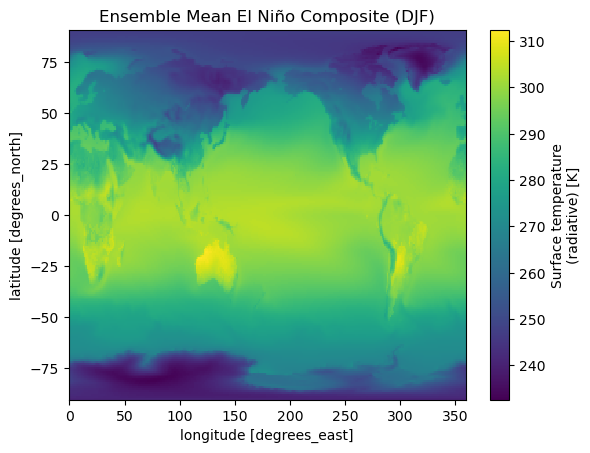

In [21]:
fig, ax = plt.subplots()

comp_mean.sel(season="DJF").plot(ax=ax)

ax.set_title("Ensemble Mean El Niño Composite (DJF)")

plt.show()

## Plot ENSO PDF

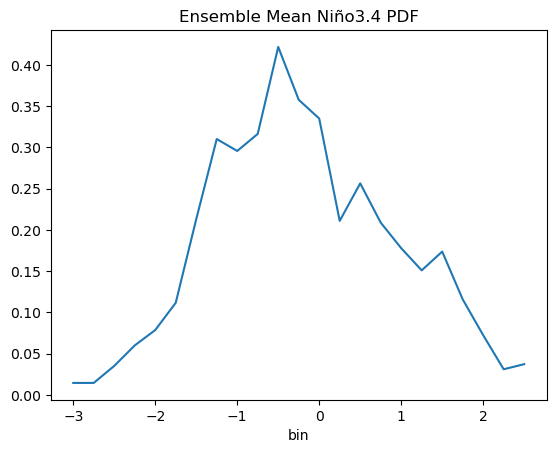

In [22]:
fig, ax = plt.subplots()

pdf_mean.plot(ax=ax)

ax.set_title("Ensemble Mean Niño3.4 PDF")

plt.show()